<a href="https://colab.research.google.com/github/AzizaZaman101/RT-IoT2022_Multi-Class_IoT_Attack_Detection_ML/blob/main/notebooks/RT_IoT2022_Multi_Class_IoT_Attack_Detection_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Introduction

This project showcases the machine learning pipeline for multi-class classification of IoT network traffic using the ***RT-IoT2022 dataset*** - as suggested in the project requirements.

## 2. Import Libraries

In [ ]:
import pandas as pd # works with tables and structured data --> dataframe
import numpy as np # highly optimized numerical operations
import matplotlib.pyplot as plt # plotting library
import seaborn as sns # for statistical visualization


In [ ]:
from google.colab import files # makes colabs file upload functionalities into python

## 3. Dataset Loading

In [ ]:
uploaded = files.upload() # to search for files/zip of files that we want to upload from the computer

Saving rt-iot2022.zip to rt-iot2022 (1).zip


In [ ]:
import zipfile # works with zip archive

zip_filename = list(uploaded.keys())[0] # to give the name of the first uploaded file name

with zipfile.ZipFile(zip_filename, 'r') as zip_ref: # 'r' is the zip file reference to drive
    print(zip_ref.namelist())

['RT_IOT2022']


In [ ]:
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    for info in zip_ref.infolist():
        print("Name:", info.filename)

Name: RT_IOT2022


## 4. Dataset Understanding

In [ ]:
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    info = zip_ref.getinfo('RT_IOT2022')

    print("File name:", info.filename)
    print("File size:", info.file_size, "bytes")
    print("Compressed size:", info.compress_size, "bytes")

File name: RT_IOT2022
File size: 54781794 bytes
Compressed size: 3445425 bytes


In [ ]:
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    with zip_ref.open('RT_IOT2022') as file:
        df = pd.read_csv(file, index_col=0) # first column of original file as row index, hence the row numbers in the first column

In [ ]:
df.head()

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [ ]:
df.shape # how big is the dataset

(123117, 84)

In [ ]:
for i, column in enumerate(df.columns, start=1): # to check how many columns we have
    print(i, column)

1 id.orig_p
2 id.resp_p
3 proto
4 service
5 flow_duration
6 fwd_pkts_tot
7 bwd_pkts_tot
8 fwd_data_pkts_tot
9 bwd_data_pkts_tot
10 fwd_pkts_per_sec
11 bwd_pkts_per_sec
12 flow_pkts_per_sec
13 down_up_ratio
14 fwd_header_size_tot
15 fwd_header_size_min
16 fwd_header_size_max
17 bwd_header_size_tot
18 bwd_header_size_min
19 bwd_header_size_max
20 flow_FIN_flag_count
21 flow_SYN_flag_count
22 flow_RST_flag_count
23 fwd_PSH_flag_count
24 bwd_PSH_flag_count
25 flow_ACK_flag_count
26 fwd_URG_flag_count
27 bwd_URG_flag_count
28 flow_CWR_flag_count
29 flow_ECE_flag_count
30 fwd_pkts_payload.min
31 fwd_pkts_payload.max
32 fwd_pkts_payload.tot
33 fwd_pkts_payload.avg
34 fwd_pkts_payload.std
35 bwd_pkts_payload.min
36 bwd_pkts_payload.max
37 bwd_pkts_payload.tot
38 bwd_pkts_payload.avg
39 bwd_pkts_payload.std
40 flow_pkts_payload.min
41 flow_pkts_payload.max
42 flow_pkts_payload.tot
43 flow_pkts_payload.avg
44 flow_pkts_payload.std
45 fwd_iat.min
46 fwd_iat.max
47 fwd_iat.tot
48 fwd_iat.avg
49 fw

In [ ]:
numerical_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(exclude='number').columns

print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

print("\nCategorical columns:")
print(categorical_columns.tolist())

Number of numerical columns: 81
Number of categorical columns: 3

Categorical columns:
['proto', 'service', 'Attack_type']


In [ ]:
dataset_summary = pd.DataFrame({ # making a dataframe to check all the columns values, missing values, nunique values, etc
    'Column': df.columns,
    'Data_Type': df.dtypes.astype(str).values,
    'Missing_Values': df.isnull().sum().values,
    'Unique_Values': df.nunique().values,
})

dataset_summary

,Column,Data_Type,Missing_Values,Unique_Values
0,id.orig_p,int64,0,65478
1,id.resp_p,int64,0,1809
2,proto,object,0,3
3,service,object,0,10
4,flow_duration,float64,0,16383
...,...,...,...,...
79,idle.std,float64,0,1001
80,fwd_init_window_size,int64,0,20
81,bwd_init_window_size,int64,0,56
82,fwd_last_window_size,int64,0,109


In [ ]:
missing_values = df.isnull().sum() # to check if there are any missing values in the columns, and keeping the columns where at most one value is missing

missing_values = missing_values[missing_values > 0]

missing_values

,0





Here, Attack_type is our target variable - meaning the variables value we want to predict.

In [ ]:
df['Attack_type'].unique() # how many unique values are there under this variable

array(['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb', 'ARP_poisioning',
       'DDOS_Slowloris', 'DOS_SYN_Hping', 'Metasploit_Brute_Force_SSH',
       'NMAP_FIN_SCAN', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan',
       'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN'], dtype=object)

In [ ]:
# count the number of records in each attack class
attack_counts = df['Attack_type'].value_counts().reset_index()

# rename the columns
attack_counts.columns = ['Attack_type', 'Number_of_Records']

# calculate the percentage of the total dataset
attack_counts['Percentage'] = (
    attack_counts['Number_of_Records'] / len(df) * 100
).round(2)

# display the final table
attack_counts

,Attack_type,Number_of_Records,Percentage
0,DOS_SYN_Hping,94659,76.89
1,Thing_Speak,8108,6.59
2,ARP_poisioning,7750,6.29
3,MQTT_Publish,4146,3.37
4,NMAP_UDP_SCAN,2590,2.10
5,NMAP_XMAS_TREE_SCAN,2010,1.63
6,NMAP_OS_DETECTION,2000,1.62
7,NMAP_TCP_scan,1002,0.81
8,DDOS_Slowloris,534,0.43
9,Wipro_bulb,253,0.21


### Plot The Target Variable

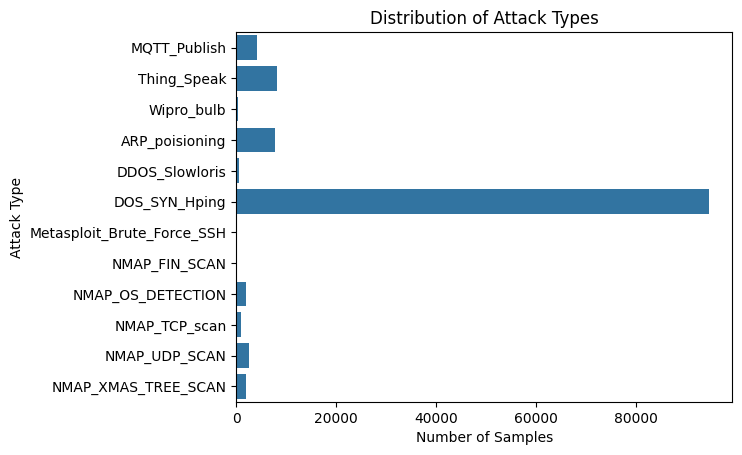

In [ ]:
sns.countplot(data=df, y='Attack_type')
plt.title('Distribution of Attack Types')
plt.xlabel('Number of Samples')
plt.ylabel('Attack Type')
plt.show()

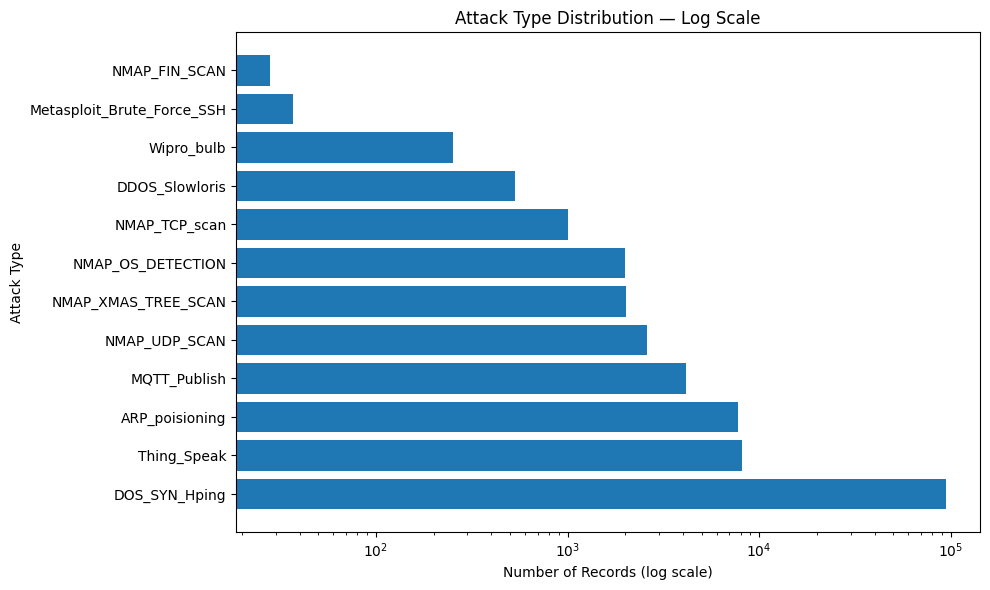

In [ ]:
plt.figure(figsize=(10, 6)) # using log scale as in the previous one almost didn't show the rarest classes

plt.barh(
    attack_counts['Attack_type'],
    attack_counts['Number_of_Records']
)

plt.xscale('log')

plt.xlabel('Number of Records (log scale)')
plt.ylabel('Attack Type')
plt.title('Attack Type Distribution — Log Scale')

plt.tight_layout()
plt.show()

This dataset is strongly imbalanced, as there are no equal distribution noticeable in the dataset. We can understand from here, splitting the data randomly would give better accuracy but leave the rarest attack types alone. So, we might have to work with weighted F1 score in the dataset in the next steps. Additionally, macro F1 gives every class equal importance, but it doesn't take frequency into account.

## 5. Data Cleaning

In [ ]:
duplicate_count = df.duplicated().sum() # to check the percentage of duplicate rows
total_rows = len(df)

duplicate_percentage = duplicate_count / total_rows * 100

print("Total rows:", total_rows)
print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Total rows: 123117
Duplicate rows: 5195
Duplicate percentage: 4.22 %


In [ ]:
class_summary = df['Attack_type'].value_counts().rename('Total_Records')

duplicate_summary = (
    df[df.duplicated(keep=False)]['Attack_type']
    .value_counts()
    .rename('Duplicate_Records')
)

class_summary = pd.concat(
    [class_summary, duplicate_summary],
    axis=1
).fillna(0)

class_summary['Duplicate_Percentage'] = (
    class_summary['Duplicate_Records']
    / class_summary['Total_Records']
    * 100
).round(2)

class_summary

,Total_Records,Duplicate_Records,Duplicate_Percentage
Attack_type,,,
DOS_SYN_Hping,94659,9082.0,9.59
Thing_Speak,8108,820.0,10.11
ARP_poisioning,7750,165.0,2.13
MQTT_Publish,4146,5.0,0.12
NMAP_UDP_SCAN,2590,10.0,0.39
NMAP_XMAS_TREE_SCAN,2010,0.0,0.00
NMAP_OS_DETECTION,2000,0.0,0.00
NMAP_TCP_scan,1002,0.0,0.00
DDOS_Slowloris,534,2.0,0.37


In [ ]:
feature_columns = [col for col in df.columns if col != 'Attack_type'] # hunts down those conflicting rows
feature_label_conflicts = (
    df.groupby(feature_columns)['Attack_type']
      .nunique()
)

feature_label_conflicts = feature_label_conflicts[
    feature_label_conflicts > 1
]

print(
    "Number of feature patterns with multiple target labels:",
    len(feature_label_conflicts)
)


Number of feature patterns with multiple target labels: 6


In [ ]:
import pandas as pd
import pandas.util

# Step 2: drop rows whose feature vector maps to more than one label -
# we can't trust these for training

# Create a set of hashed conflicting feature patterns for faster lookup
conflicting_df = feature_label_conflicts.index.to_frame(index=False)
conflicting_keys_hashed = set(pandas.util.hash_pandas_object(conflicting_df, index=False))

# Generate hash for each row in X using df[feature_columns]
df_hashed = pandas.util.hash_pandas_object(df[feature_columns], index=False)

# Create a mask for rows that are not in the conflicting keys
mask_clean = ~df_hashed.isin(conflicting_keys_hashed)

# Save the results cleanly directly into df_clean
df_clean = df[mask_clean]

print("Dropped for label conflicts:", (~mask_clean).sum())
print("Dataframe shape after conflict drop:", df_clean.shape)


Dropped for label conflicts: 128
Dataframe shape after conflict drop: (122989, 84)


In [ ]:
# Step 3: now dedup — every remaining feature vector has exactly one label

# 1. Deduplicate the cleaned dataframe directly
df_dedup = df_clean.drop_duplicates()

print("Rows before dedup:", len(df_clean))
print("Rows after dedup:", len(df_dedup))
print("Removed as duplicates:", len(df_clean) - len(df_dedup))


Rows before dedup: 122989
Rows after dedup: 117909
Removed as duplicates: 5080


In [ ]:
# conflicting_features = feature_label_conflicts.index.to_frame(index=False)

# conflicting_features

In [ ]:
# conflicting_rows = df.merge(
#     conflicting_features,
#     on=feature_columns,
#     how='inner'
# )

# conflicting_rows[['Attack_type'] + feature_columns]

In [ ]:
# conflict_summary = (
#     conflicting_rows
#     .groupby(feature_columns)['Attack_type']
#     .agg(
#         Number_of_Labels='nunique',
#         Labels=lambda x: sorted(x.unique()),
#         Number_of_Rows='size'
#     )
#     .reset_index()
# )

# conflict_summary[['Number_of_Labels', 'Labels', 'Number_of_Rows']]

In [ ]:
# conflict_label_counts = (
#     conflicting_rows
#     .groupby(feature_columns + ['Attack_type'])
#     .size()
#     .reset_index(name='Count')
# )

# conflict_label_counts[
#     ['id.orig_p', 'id.resp_p', 'proto', 'service', 'Attack_type', 'Count']
# ]


In [ ]:
# conflict_rows_count = len(conflicting_rows)

# print("Observations involved in conflicting feature patterns:", conflict_rows_count)
# print(
#     "Percentage of dataset:",
#     round(conflict_rows_count / len(df) * 100, 4),
#     "%"
# )

In [ ]:
# how many unique values exist in each column
unique_counts = df.nunique().sort_values()

unique_counts.head(15)

,0
bwd_URG_flag_count,1
fwd_URG_flag_count,2
proto,3
flow_ECE_flag_count,5
flow_CWR_flag_count,5
fwd_header_size_min,7
bwd_header_size_min,7
fwd_header_size_max,8
flow_SYN_flag_count,8
flow_RST_flag_count,9


In [ ]:
# to find constant columns, which doesn't change its value throughout the dataset
constant_columns = unique_counts[unique_counts == 1]

print("Number of constant columns:", len(constant_columns))
print("\nConstant columns:")
print(constant_columns)

Number of constant columns: 1

Constant columns:
bwd_URG_flag_count    1
dtype: int64


In [ ]:
import numpy as np


# Check for negative numbers in count and duration fields
count_and_duration_cols = [c for c in numerical_columns if any(k in c for k in ['pkts', 'bytes', 'duration', 'iat', 'flag_count'])]
negative_check = (df[count_and_duration_cols] < 0).sum()
negative_check = negative_check[negative_check > 0]
print(f"Columns with negative values:\n{negative_check if len(negative_check) > 0 else 'None (0)'}\n")

# Check for Infinite values (Inf / -Inf)
inf_check = np.isinf(df[numerical_columns]).sum()
inf_check = inf_check[inf_check > 0]
print(f"Columns with Infinite values:\n{inf_check if len(inf_check) > 0 else 'None (0)'}\n")

# Check for invalid network ports (Valid network ports must be between 0 and 65535)
invalid_ports = df[
    (df['id.orig_p'] < 0) | (df['id.orig_p'] > 65535) |
    (df['id.resp_p'] < 0) | (df['id.resp_p'] > 65535)
]
print(f"Number of rows with invalid port numbers: {len(invalid_ports)}\n")

# Check for structural packet inconsistencies
inconsistent_fwd = df[df['fwd_data_pkts_tot'] > df['fwd_pkts_tot']]
inconsistent_bwd = df[df['bwd_data_pkts_tot'] > df['bwd_pkts_tot']]
print(f"Forward inconsistent rows: {len(inconsistent_fwd)}")
print(f"Backward inconsistent rows: {len(inconsistent_bwd)}")


Columns with negative values:
None (0)

Columns with Infinite values:
None (0)

Number of rows with invalid port numbers: 0

Forward inconsistent rows: 0
Backward inconsistent rows: 0


In [ ]:
numerical_summary = df[numerical_columns].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
id.orig_p,123117.0,3.463926e+04,1.907062e+04,0.0,17702.000000,37221.000000,50971.000000,6.553500e+04
id.resp_p,123117.0,1.014305e+03,5.256372e+03,0.0,21.000000,21.000000,21.000000,6.538900e+04
flow_duration,123117.0,3.809566e+00,1.300054e+02,0.0,0.000001,0.000004,0.000005,2.172834e+04
fwd_pkts_tot,123117.0,2.268826e+00,2.233656e+01,0.0,1.000000,1.000000,1.000000,4.345000e+03
bwd_pkts_tot,123117.0,1.909509e+00,3.301831e+01,0.0,1.000000,1.000000,1.000000,1.011200e+04
...,...,...,...,...,...,...,...,...
idle.avg,123117.0,1.664985e+06,9.007064e+06,0.0,0.000000,0.000000,0.000000,3.000000e+08
idle.std,123117.0,4.550183e+04,1.091361e+06,0.0,0.000000,0.000000,0.000000,1.208029e+08
fwd_init_window_size,123117.0,6.118905e+03,1.871631e+04,0.0,64.000000,64.000000,64.000000,6.553500e+04
bwd_init_window_size,123117.0,2.739776e+03,1.001885e+04,0.0,0.000000,0.000000,0.000000,6.553500e+04


In [ ]:
# conflict_view = conflicting_rows[
#     [
#         'id.orig_p',
#         'id.resp_p',
#         'proto',
#         'service',
#         'flow_duration',
#         'fwd_pkts_tot',
#         'bwd_pkts_tot',
#         'fwd_data_pkts_tot',
#         'bwd_data_pkts_tot',
#         'Attack_type'
#     ]
# ]

# conflict_view.drop_duplicates().sort_values(
#     by=['id.orig_p', 'id.resp_p', 'Attack_type']
# )

In [ ]:
print(df['proto'].unique())
print(df['service'].unique())

['tcp' 'udp' 'icmp']
['mqtt' '-' 'http' 'dns' 'ntp' 'ssl' 'dhcp' 'irc' 'ssh' 'radius']


In [ ]:
# Consolidate all cleaning decisions into one clean dataframe

# Drop the constant column identified earlier (bwd_URG_flag_count)
df_clean = df.drop(columns=constant_columns.index, errors='ignore')

# Drop the 6 unique network patterns that map to conflicting labels
feature_columns_clean = [c for c in feature_columns if c not in constant_columns.index]
conflicting_patterns = df_clean.groupby(feature_columns_clean).filter(lambda x: x['Attack_type'].nunique() > 1).index
df_clean = df_clean.drop(index=conflicting_patterns)

# Drop remaining standard duplicates
df_clean = df_clean.drop_duplicates()

print("Final shape after cleaning:", df_clean.shape)

Final shape after cleaning: (117378, 83)


In [ ]:
# Recompute column-type lists to match the cleaned df
numerical_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(exclude='number').columns

print("Numerical columns:", len(numerical_columns))
print("Categorical columns:", len(categorical_columns))

Numerical columns: 81
Categorical columns: 3


## 6. Explanatory Data Analysis (EDA)

In [ ]:
# calculates the Skewness of numerical features and sorts them from the most skewed to the least skewed

numeric_stats = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Std': df[numerical_columns].std(),
    'Min': df[numerical_columns].min(),
    'Max': df[numerical_columns].max(),
    'Skewness': df[numerical_columns].skew()
})

numeric_stats.sort_values(
    by='Skewness',
    key=lambda x: x.abs(),
    ascending=False
).head(20)

,Mean,Median,Std,Min,Max,Skewness
bwd_bulk_bytes,1.552337e+02,0.000000,1.959295e+04,0.0,6.805208e+06,340.497528
bwd_bulk_packets,1.311128e-01,0.000000,1.454655e+01,0.0,5.052500e+03,340.490987
active.std,2.353599e+04,0.000000,1.477935e+06,0.0,4.774862e+08,287.992755
bwd_pkts_payload.tot,5.129981e+02,0.000000,4.244143e+04,0.0,1.361042e+07,280.814630
flow_pkts_payload.tot,7.345172e+02,120.000000,4.296599e+04,0.0,1.361058e+07,271.972274
bwd_header_size_tot,4.662690e+01,20.000000,1.028229e+03,0.0,3.235920e+05,269.075835
bwd_data_pkts_tot,8.202604e-01,0.000000,3.229395e+01,0.0,1.010500e+04,264.030712
bwd_pkts_tot,1.909509e+00,1.000000,3.301831e+01,0.0,1.011200e+04,249.909345
fwd_iat.min,8.843266e+03,0.000000,1.226521e+06,0.0,3.002526e+08,238.881011
active.max,1.785898e+05,4.053116,3.011784e+06,0.0,8.480979e+08,234.461542


In [ ]:
# calculates the percentage of zeros in each column - sparsity

existing_numerical_cols = [col for col in numerical_columns if col in df_clean.columns]

zero_percentage = (df_clean[existing_numerical_cols] == 0).mean() * 100

# Filter for columns that are "zero-heavy" (95% or more zeros) and format as a table
zero_heavy = zero_percentage[zero_percentage >= 95].sort_values(ascending=False)
zero_heavy_df = zero_heavy.to_frame(name='Zero_Percentage')

print(f"Found {len(zero_heavy)} columns that contain over 95% zero values:")
zero_heavy_df

Found 15 columns that contain over 95% zero values:


,Zero_Percentage
flow_CWR_flag_count,99.946327
flow_ECE_flag_count,99.945475
fwd_bulk_bytes,99.791273
fwd_bulk_packets,99.791273
fwd_bulk_rate,99.791273
idle.std,99.160831
bwd_bulk_bytes,99.065413
bwd_bulk_rate,99.065413
bwd_bulk_packets,99.065413
active.std,98.594285


In [ ]:
# Columns that are 0 for almost every row carry almost no signal
near_zero_cols = zero_percentage[zero_percentage >= 99].index.tolist()
print(f"{len(near_zero_cols)} near-zero-variance columns:")
print(near_zero_cols)

9 near-zero-variance columns:
['flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_bulk_bytes', 'bwd_bulk_bytes', 'fwd_bulk_packets', 'bwd_bulk_packets', 'fwd_bulk_rate', 'bwd_bulk_rate', 'idle.std']


In [ ]:
# outputs exactly how many times each unique text value appears in protocol

protocol_counts = (
    df['proto']
    .value_counts()
    .reset_index()
)

protocol_counts.columns = ['Protocol', 'Number_of_Records']

protocol_counts

,Protocol,Number_of_Records
0,tcp,110427
1,udp,12633
2,icmp,57


In [ ]:
# outputs exactly how many times each unique text value appears in service

service_counts = (
    df['service']
    .value_counts()
    .reset_index()
)

service_counts.columns = ['Service', 'Number_of_Records']

service_counts

,Service,Number_of_Records
0,-,102861
1,dns,9753
2,mqtt,4132
3,http,3464
4,ssl,2663
5,ntp,121
6,dhcp,50
7,irc,43
8,ssh,28
9,radius,2


In [ ]:
# df['flow_duration'].describe()
# df['fwd_pkts_tot'].describe()
# df['bwd_pkts_tot'].describe()


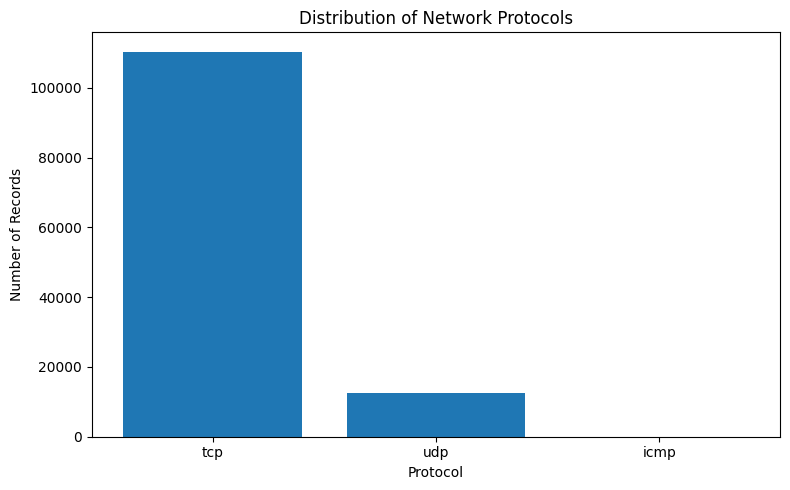

In [ ]:
plt.figure(figsize=(8, 5))

protocol_counts = df['proto'].value_counts()

plt.bar(
    protocol_counts.index,
    protocol_counts.values
)

plt.xlabel('Protocol')
plt.ylabel('Number of Records')
plt.title('Distribution of Network Protocols')

plt.tight_layout()
plt.show()

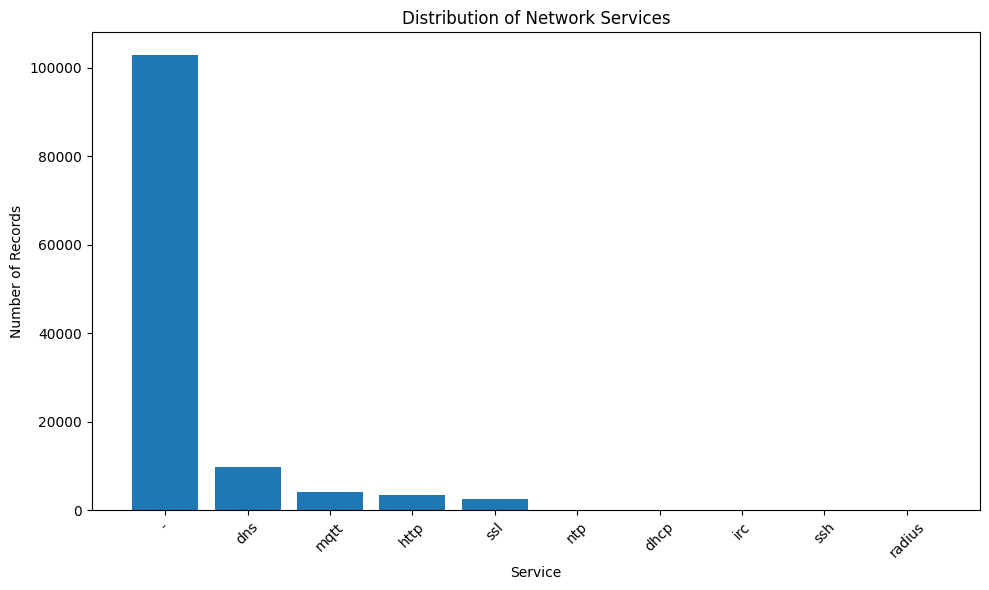

In [ ]:
plt.figure(figsize=(10, 6))

service_counts = df['service'].value_counts()

plt.bar(
    service_counts.index,
    service_counts.values
)

plt.xlabel('Service')
plt.ylabel('Number of Records')
plt.title('Distribution of Network Services')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

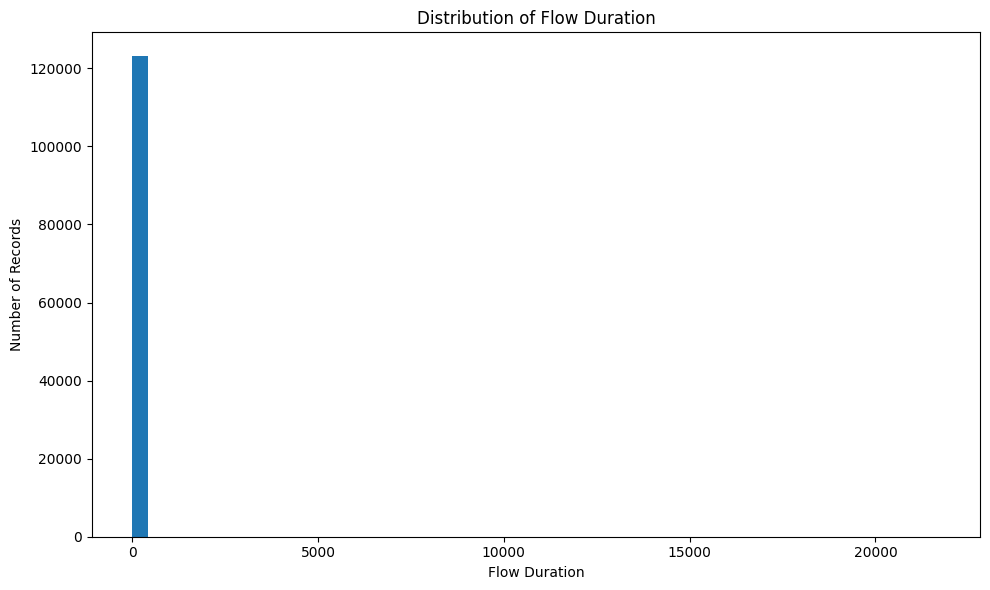

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df['flow_duration'], bins=50)

plt.xlabel('Flow Duration')
plt.ylabel('Number of Records')
plt.title('Distribution of Flow Duration')

plt.tight_layout()
plt.show()

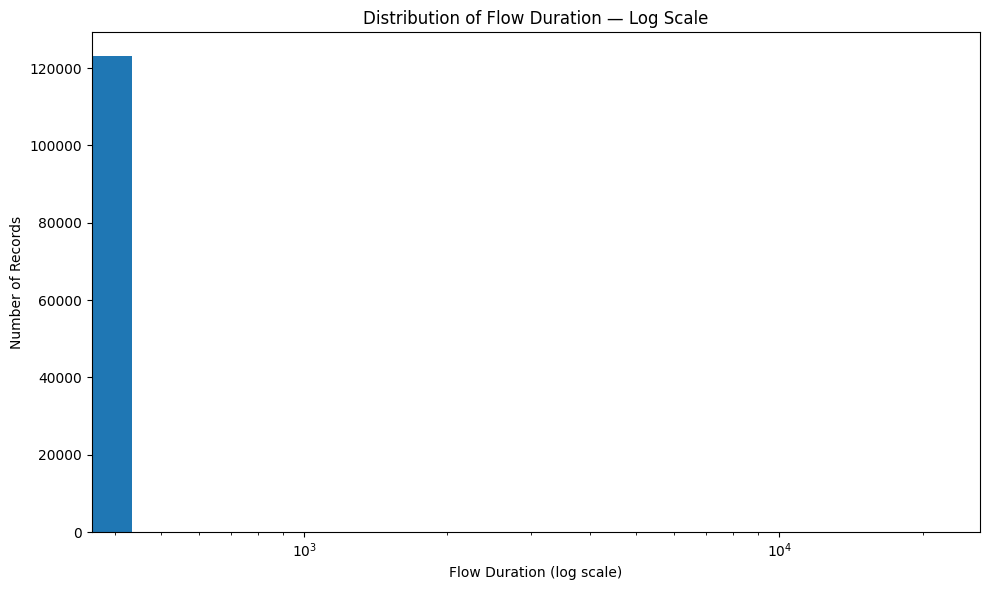

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df['flow_duration'], bins=50)

plt.xscale('log')

plt.xlabel('Flow Duration (log scale)')
plt.ylabel('Number of Records')
plt.title('Distribution of Flow Duration — Log Scale')

plt.tight_layout()
plt.show()

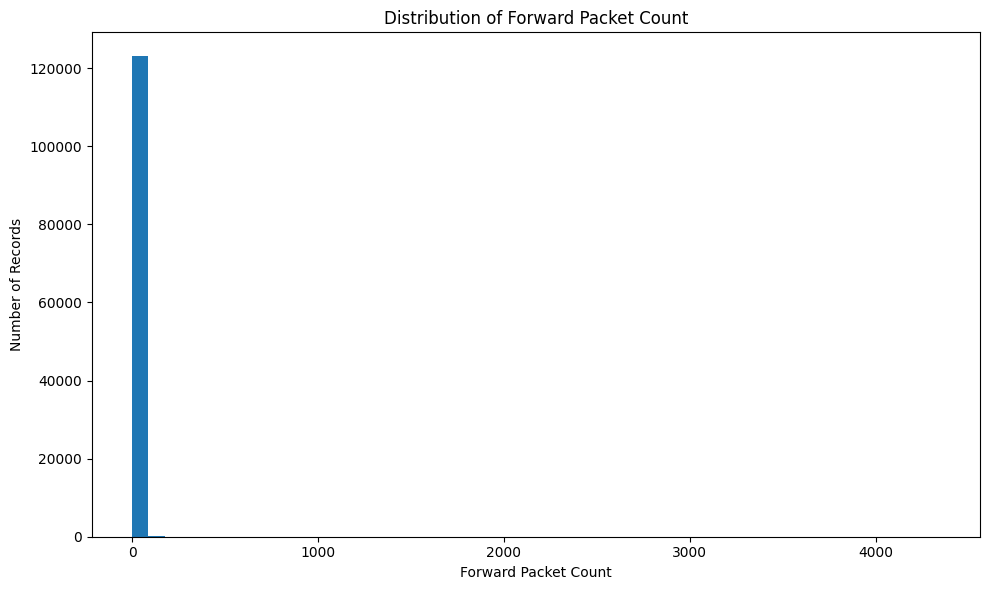

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df['fwd_pkts_tot'], bins=50)

plt.xlabel('Forward Packet Count')
plt.ylabel('Number of Records')
plt.title('Distribution of Forward Packet Count')

plt.tight_layout()
plt.show()

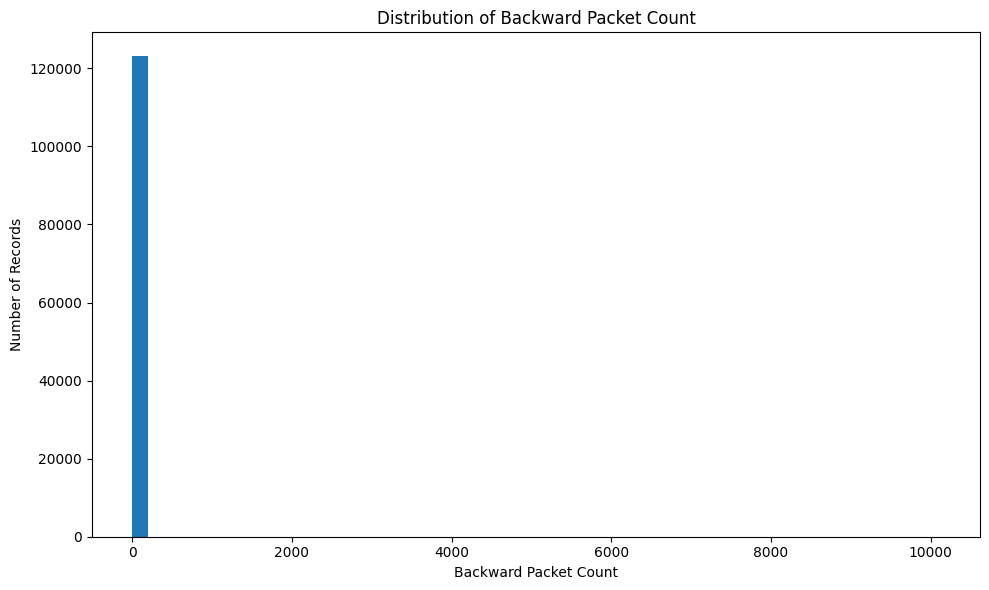

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df['bwd_pkts_tot'], bins=50)

plt.xlabel('Backward Packet Count')
plt.ylabel('Number of Records')
plt.title('Distribution of Backward Packet Count')

plt.tight_layout()
plt.show()

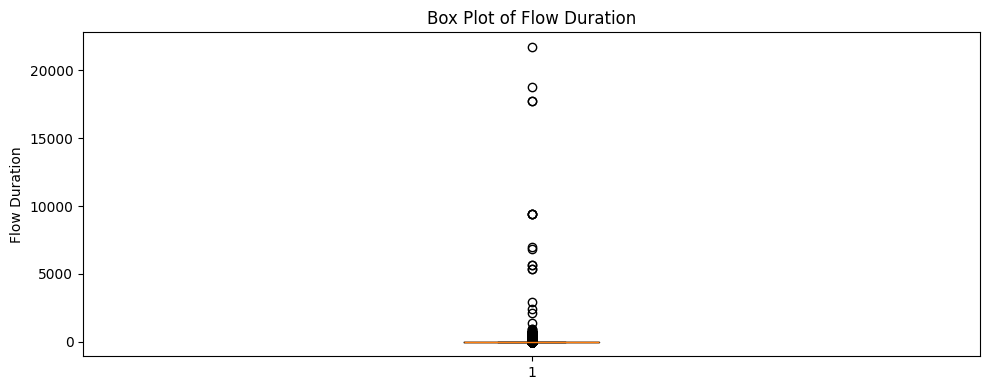

In [ ]:
plt.figure(figsize=(10, 4))

plt.boxplot(df['flow_duration'])

plt.ylabel('Flow Duration')
plt.title('Box Plot of Flow Duration')

plt.tight_layout()
plt.show()

In [ ]:
# calculates the mathematical Range (Maximum value - Minimum value) for numerical features and sorting them from largest to smallest

feature_ranges = (
    df[numerical_columns].max()
    - df[numerical_columns].min()
).sort_values(ascending=False)

feature_ranges.head(20)

,0
fwd_iat.tot,2.172834e+10
flow_iat.tot,2.172834e+10
idle.tot,2.096777e+10
bwd_iat.tot,1.876117e+10
active.tot,2.945221e+09
active.max,8.480979e+08
active.std,4.774862e+08
active.avg,4.374931e+08
active.min,3.125080e+08
fwd_iat.min,3.002526e+08


In [ ]:
# calculates the correlation matrix and visualizes it as a heatmap to see how closely related these network features are to each other

selected_features = [
    'flow_duration',
    'fwd_pkts_tot',
    'bwd_pkts_tot',
    'fwd_pkts_per_sec',
    'bwd_pkts_per_sec',
    'flow_pkts_per_sec'
]

correlation_matrix = df[selected_features].corr()

correlation_matrix

,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec
flow_duration,1.000000,0.741707,0.071395,-0.027805,-0.027799,-0.027802
fwd_pkts_tot,0.741707,1.000000,0.407452,-0.053855,-0.053875,-0.053865
bwd_pkts_tot,0.071395,0.407452,1.000000,-0.026131,-0.026121,-0.026126
fwd_pkts_per_sec,-0.027805,-0.053855,-0.026131,1.000000,0.999986,0.999997
bwd_pkts_per_sec,-0.027799,-0.053875,-0.026121,0.999986,1.000000,0.999997
flow_pkts_per_sec,-0.027802,-0.053865,-0.026126,0.999997,0.999997,1.000000


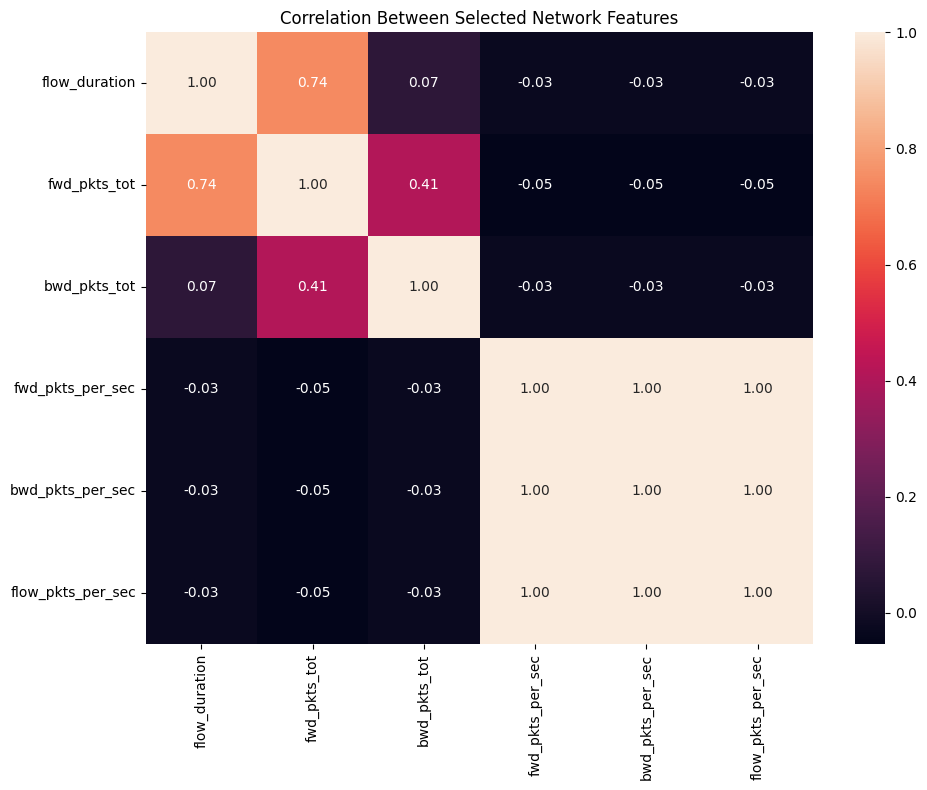

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Selected Network Features')

plt.tight_layout()
plt.show()

In [ ]:
# Find feature pairs with correlation above 0.95 (basically duplicated information)
corr = df[numerical_columns].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Dropping {len(to_drop)} redundant features:")
print(to_drop)

df_clean = df_clean.drop(columns=to_drop, errors='ignore')
print(f"Successfully dropped 24 redundant features. Remaining features: {df_clean.shape[1]}")


Dropping 24 redundant features:
['bwd_data_pkts_tot', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'bwd_header_size_tot', 'bwd_header_size_max', 'flow_ACK_flag_count', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.std', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'fwd_iat.tot', 'fwd_iat.std', 'flow_iat.max', 'flow_iat.tot', 'flow_iat.std', 'payload_bytes_per_second', 'bwd_subflow_bytes', 'fwd_bulk_packets', 'bwd_bulk_packets', 'active.std', 'idle.min', 'idle.max', 'idle.tot', 'idle.avg']
Successfully dropped 24 redundant features. Remaining features: 59


In [ ]:
# # to find outliers - but we are not going to delete the rows based on the outliers, because this is what we need in cybersecurity

# Q1 = df['flow_duration'].quantile(0.25)
# Q3 = df['flow_duration'].quantile(0.75)

# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# outliers = df[
#     (df['flow_duration'] < lower_bound) |
#     (df['flow_duration'] > upper_bound)
# ]

# print("Q1:", Q1)
# print("Q3:", Q3)
# print("IQR:", IQR)
# print("Lower bound:", lower_bound)
# print("Upper bound:", upper_bound)
# print("Number of potential outliers:", len(outliers))

In [ ]:
# # outlier identification - we had to check it, but not actually needed for the project

# outlier_by_attack = (
#     outliers['Attack_type']
#     .value_counts()
#     .reset_index()
# )

# outlier_by_attack.columns = [
#     'Attack_type',
#     'Potential_Outliers'
# ]

# outlier_by_attack

In [ ]:
# # outlier quest continues

# class_outlier_summary = (
#     df['Attack_type']
#     .value_counts()
#     .rename('Total_Records')
#     .to_frame()
# )

# class_outlier_summary['Potential_Outliers'] = (
#     outliers['Attack_type']
#     .value_counts()
# )

# class_outlier_summary['Potential_Outliers'] = (
#     class_outlier_summary['Potential_Outliers']
#     .fillna(0)
# )

# class_outlier_summary['Outlier_Percentage'] = (
#     class_outlier_summary['Potential_Outliers']
#     / class_outlier_summary['Total_Records']
#     * 100
# ).round(2)

# class_outlier_summary

In [ ]:
# # illustrate the extreme data skewness

# df['flow_duration'].quantile(
#     [0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
# )

# df['flow_duration'].nlargest(20)

In [ ]:
# counts the quantile, median values of all the types of attacks

flow_duration_by_class = (
    df.groupby('Attack_type')['flow_duration']
      .agg(
          Count='count',
          Mean='mean',
          Median='median',
          Q1=lambda x: x.quantile(0.25),
          Q3=lambda x: x.quantile(0.75),
          P95=lambda x: x.quantile(0.95),
          Max='max'
      )
      .sort_values('Median', ascending=False)
)

flow_duration_by_class.round(6)

,Count,Mean,Median,Q1,Q3,P95,Max
Attack_type,,,,,,,
MQTT_Publish,4146,43.397013,44.067645,30.022991,61.973034,62.101409,353.112391
DDOS_Slowloris,534,14.699148,20.088963,0.003817,30.557698,30.794878,30.870463
Metasploit_Brute_Force_SSH,37,3.006557,2.030317,1.417588,2.258765,12.941147,29.289262
Wipro_bulb,253,586.845727,0.803326,0.027666,31.285402,1591.466091,21728.335578
Thing_Speak,8108,0.934471,0.114787,0.029932,0.878177,1.542538,184.414081
ARP_poisioning,7750,15.893538,0.000637,0.000000,0.307533,116.078674,5341.392332
NMAP_XMAS_TREE_SCAN,2010,0.001171,0.000007,0.000006,0.000008,0.000029,2.260214
NMAP_OS_DETECTION,2000,0.000008,0.000006,0.000005,0.000007,0.000026,0.000048
NMAP_TCP_scan,1002,0.000019,0.000004,0.000002,0.000005,0.000011,0.005989


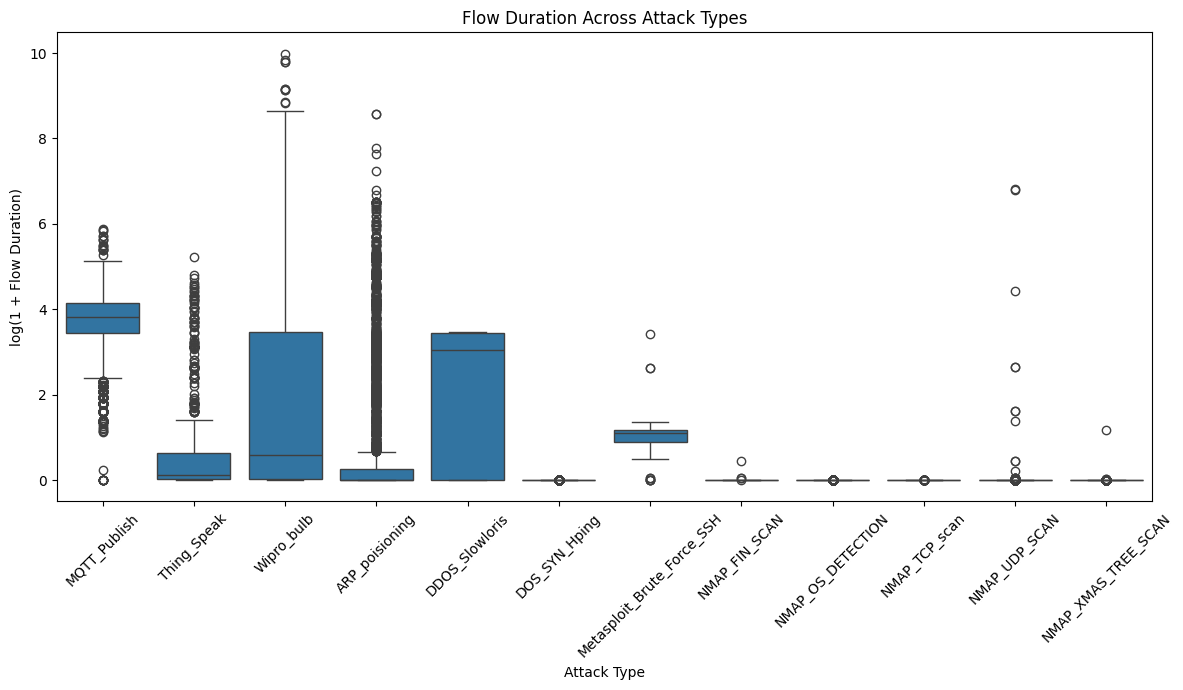

In [ ]:
# plotting the flow duration

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='Attack_type',
    y=np.log1p(df['flow_duration'])
)

plt.xlabel('Attack Type')
plt.ylabel('log(1 + Flow Duration)')
plt.title('Flow Duration Across Attack Types')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# compares the volume of data packets they send

flow_duration_class_summary = (
    df.groupby('Attack_type')['flow_duration']
      .agg(['mean', 'median', 'min', 'max'])
      .sort_values('median', ascending=False)
)

flow_duration_class_summary.round(6)

,mean,median,min,max
Attack_type,,,,
MQTT_Publish,43.397013,44.067645,0.000000,353.112391
DDOS_Slowloris,14.699148,20.088963,0.000000,30.870463
Metasploit_Brute_Force_SSH,3.006557,2.030317,0.000000,29.289262
Wipro_bulb,586.845727,0.803326,0.000000,21728.335578
Thing_Speak,0.934471,0.114787,0.000000,184.414081
ARP_poisioning,15.893538,0.000637,0.000000,5341.392332
NMAP_XMAS_TREE_SCAN,0.001171,0.000007,0.000000,2.260214
NMAP_OS_DETECTION,0.000008,0.000006,0.000001,0.000048
NMAP_TCP_scan,0.000019,0.000004,0.000001,0.005989


In [ ]:
fwd_packets_by_class = (
    df.groupby('Attack_type')['fwd_pkts_tot']
      .agg(
          Count='count',
          Mean='mean',
          Median='median',
          Q1=lambda x: x.quantile(0.25),
          Q3=lambda x: x.quantile(0.75),
          P95=lambda x: x.quantile(0.95),
          Max='max'
      )
      .sort_values('Median', ascending=False)
)

fwd_packets_by_class.round(4)

,Count,Mean,Median,Q1,Q3,P95,Max
Attack_type,,,,,,,
Metasploit_Brute_Force_SSH,37,12.2162,14.0,14.0,15.00,15.00,33
MQTT_Publish,4146,10.1720,10.0,9.0,10.00,10.00,1661
Wipro_bulb,253,80.5296,10.0,1.0,16.00,157.40,4345
DDOS_Slowloris,534,6.0412,6.0,4.0,7.75,8.00,11
Thing_Speak,8108,5.3925,2.0,2.0,7.00,14.00,130
ARP_poisioning,7750,8.2969,2.0,1.0,6.00,25.00,2166
DOS_SYN_Hping,94659,1.0000,1.0,1.0,1.00,1.00,1
NMAP_FIN_SCAN,28,1.2143,1.0,1.0,1.00,1.65,6
NMAP_TCP_scan,1002,1.0100,1.0,1.0,1.00,1.00,3


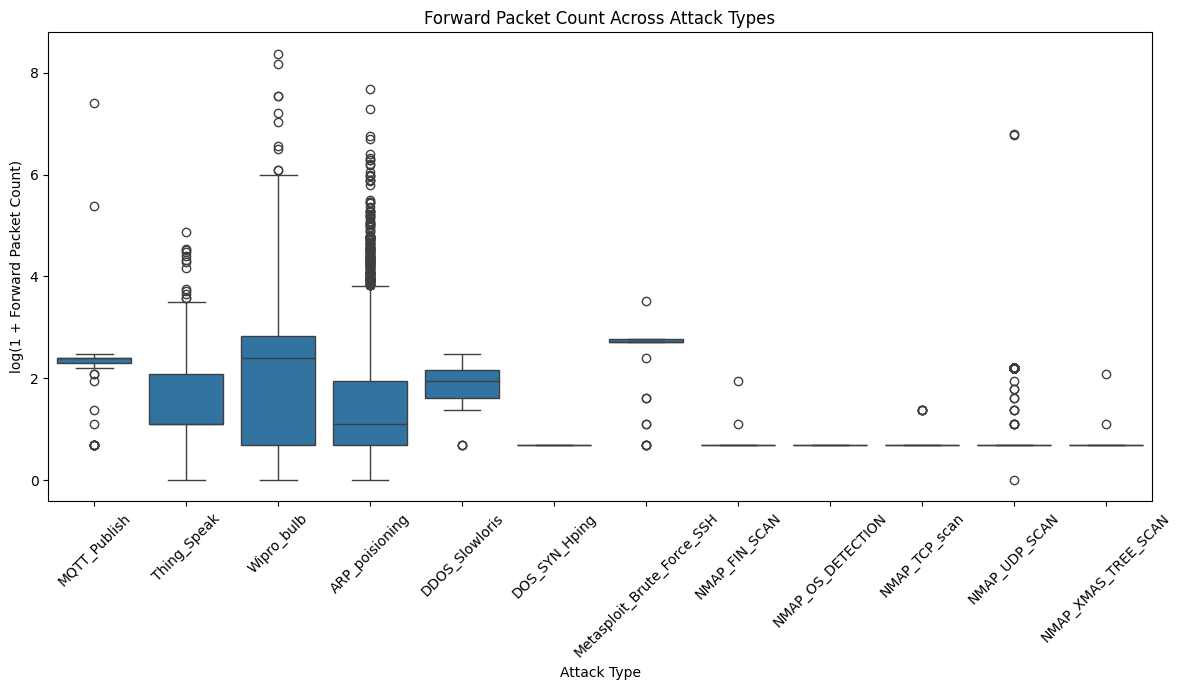

In [ ]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='Attack_type',
    y=np.log1p(df['fwd_pkts_tot'])
)

plt.xlabel('Attack Type')
plt.ylabel('log(1 + Forward Packet Count)')
plt.title('Forward Packet Count Across Attack Types')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
protocol_attack_table = pd.crosstab(
    df['Attack_type'],
    df['proto']
)

protocol_attack_table

proto,icmp,tcp,udp
Attack_type,,,
ARP_poisioning,8,1927,5815
DDOS_Slowloris,0,529,5
DOS_SYN_Hping,0,94659,0
MQTT_Publish,0,4146,0
Metasploit_Brute_Force_SSH,0,29,8
NMAP_FIN_SCAN,0,25,3
NMAP_OS_DETECTION,0,2000,0
NMAP_TCP_scan,0,1002,0
NMAP_UDP_SCAN,2,142,2446


In [ ]:
protocol_attack_percentage = pd.crosstab(
    df['Attack_type'],
    df['proto'],
    normalize='index'
) * 100

protocol_attack_percentage.round(2)

proto,icmp,tcp,udp
Attack_type,,,
ARP_poisioning,0.10,24.86,75.03
DDOS_Slowloris,0.00,99.06,0.94
DOS_SYN_Hping,0.00,100.00,0.00
MQTT_Publish,0.00,100.00,0.00
Metasploit_Brute_Force_SSH,0.00,78.38,21.62
NMAP_FIN_SCAN,0.00,89.29,10.71
NMAP_OS_DETECTION,0.00,100.00,0.00
NMAP_TCP_scan,0.00,100.00,0.00
NMAP_UDP_SCAN,0.08,5.48,94.44


<Figure size 1000x700 with 0 Axes>

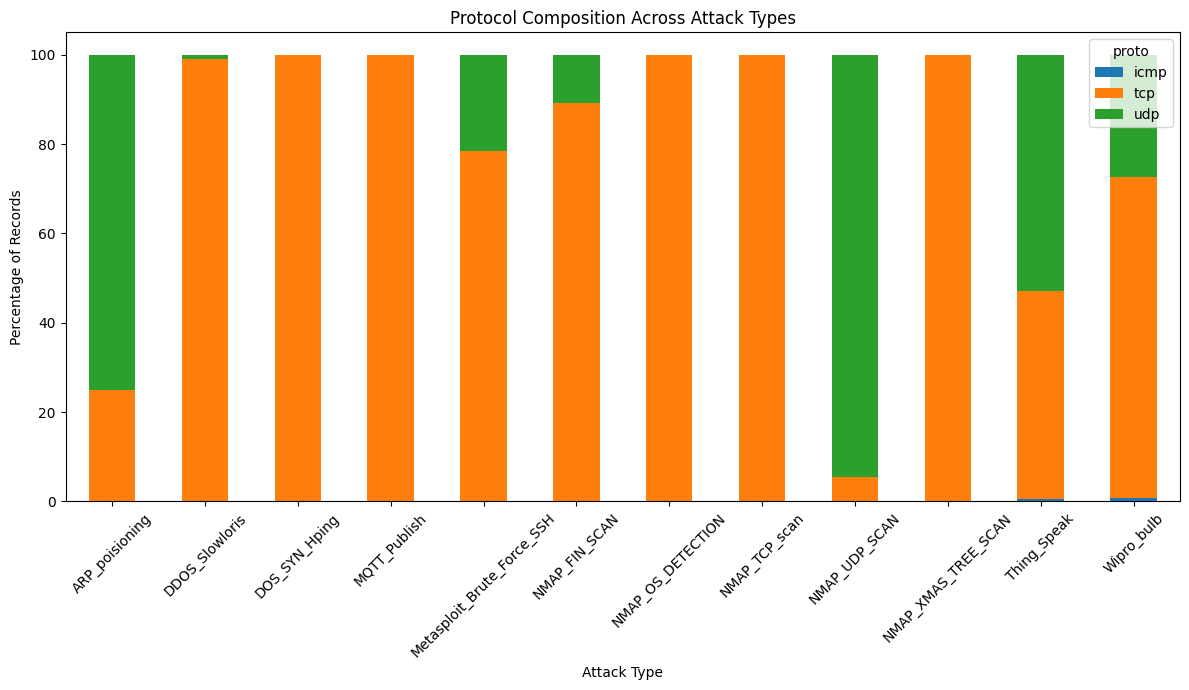

In [ ]:
plt.figure(figsize=(10, 7))

protocol_attack_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.xlabel('Attack Type')
plt.ylabel('Percentage of Records')
plt.title('Protocol Composition Across Attack Types')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Each vertical bar represents one Attack Type or Normal Device (labeled at the bottom). The bar always stretches to 100%, and the color breakdown shows the exact mix of internet protocols (tcp, udp, icmp) that traffic relies on. The colors in legend on the right🟧 Orange = TCP (Transmission Control Protocol: Safe, verified data transfer)🟩 Green = UDP (User Datagram Protocol: Fast, fire-and-forget data transfer)🟦 Blue = ICMP (Internet Control Message Protocol: Network diagnostic ping messages)

In [ ]:
service_attack_table = pd.crosstab(
    df['Attack_type'],
    df['service']
)

service_attack_table

service,-,dhcp,dns,http,irc,mqtt,ntp,radius,ssh,ssl
Attack_type,,,,,,,,,,
ARP_poisioning,546,26,5583,129,0,0,7,0,0,1459
DDOS_Slowloris,6,2,3,523,0,0,0,0,0,0
DOS_SYN_Hping,94659,0,0,0,0,0,0,0,0,0
MQTT_Publish,11,0,0,3,0,4132,0,0,0,0
Metasploit_Brute_Force_SSH,0,0,8,1,0,0,0,0,28,0
NMAP_FIN_SCAN,24,0,3,1,0,0,0,0,0,0
NMAP_OS_DETECTION,2000,0,0,0,0,0,0,0,0,0
NMAP_TCP_scan,1002,0,0,0,0,0,0,0,0,0
NMAP_UDP_SCAN,2411,3,31,139,0,0,4,2,0,0


In [ ]:
service_attack_percentage = pd.crosstab(
    df['Attack_type'],
    df['service'],
    normalize='index'
) * 100

service_attack_percentage.round(2)

service,-,dhcp,dns,http,irc,mqtt,ntp,radius,ssh,ssl
Attack_type,,,,,,,,,,
ARP_poisioning,7.05,0.34,72.04,1.66,0.0,0.00,0.09,0.00,0.00,18.83
DDOS_Slowloris,1.12,0.37,0.56,97.94,0.0,0.00,0.00,0.00,0.00,0.00
DOS_SYN_Hping,100.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00
MQTT_Publish,0.27,0.00,0.00,0.07,0.0,99.66,0.00,0.00,0.00,0.00
Metasploit_Brute_Force_SSH,0.00,0.00,21.62,2.70,0.0,0.00,0.00,0.00,75.68,0.00
NMAP_FIN_SCAN,85.71,0.00,10.71,3.57,0.0,0.00,0.00,0.00,0.00,0.00
NMAP_OS_DETECTION,100.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00
NMAP_TCP_scan,100.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00
NMAP_UDP_SCAN,93.09,0.12,1.20,5.37,0.0,0.00,0.15,0.08,0.00,0.00


<Figure size 1400x700 with 0 Axes>

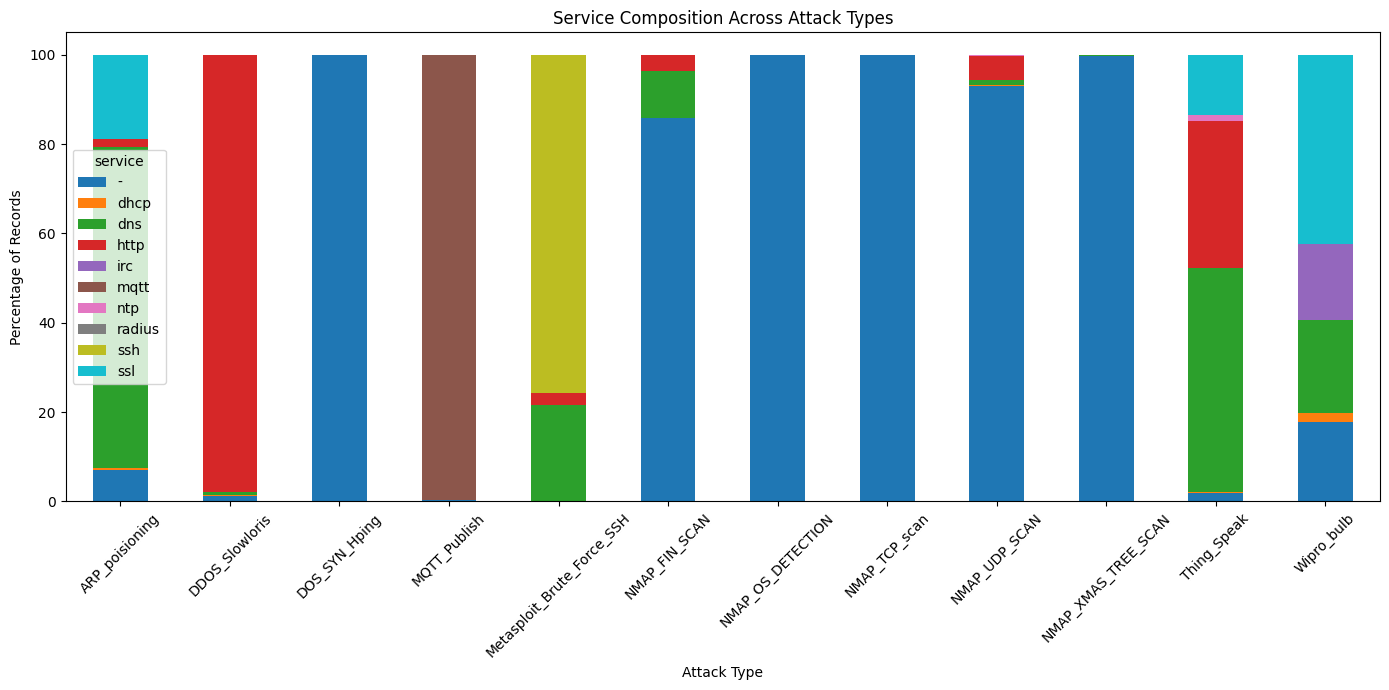

In [ ]:
plt.figure(figsize=(14, 7))

service_attack_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.xlabel('Attack Type')
plt.ylabel('Percentage of Records')
plt.title('Service Composition Across Attack Types')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
class_feature_variation = (
    df.groupby('Attack_type')[numerical_columns]
      .median()
)

feature_median_range = (
    class_feature_variation.max()
    - class_feature_variation.min()
).sort_values(ascending=False)

feature_median_range.head(20)

,0
fwd_iat.tot,4.406764e+07
flow_iat.tot,4.406764e+07
flow_iat.max,4.188855e+07
fwd_iat.max,4.188855e+07
idle.tot,4.188855e+07
idle.max,4.188855e+07
idle.avg,4.188724e+07
idle.min,4.188554e+07
payload_bytes_per_second,2.960685e+07
bwd_iat.tot,2.008696e+07


In [ ]:
# Variance-Based Feature Ranking, and it acts as the first automated phase of Feature Selection

class_feature_medians = (
    df.groupby('Attack_type')[numerical_columns]
      .median()
)

standardized_class_medians = (
    class_feature_medians - class_feature_medians.mean()
) / class_feature_medians.std()

standardized_median_range = (
    standardized_class_medians.max()
    - standardized_class_medians.min()
).sort_values(ascending=False)

standardized_median_range.head(20)

,0
bwd_subflow_pkts,3.863355
id.orig_p,3.736892
fwd_subflow_bytes,3.593209
flow_pkts_payload.max,3.587353
fwd_pkts_payload.max,3.560585
id.resp_p,3.547626
bwd_pkts_payload.max,3.522091
bwd_pkts_payload.std,3.516412
bwd_iat.tot,3.507529
bwd_iat.avg,3.504325


In [ ]:
selected_eda_features = [
    'flow_duration',
    'fwd_pkts_tot',
    'bwd_pkts_tot',
    'flow_iat.tot',
    'payload_bytes_per_second'
]

eda_class_medians = (
    df.groupby('Attack_type')[selected_eda_features]
      .median()
)

eda_class_medians

,flow_duration,fwd_pkts_tot,bwd_pkts_tot,flow_iat.tot,payload_bytes_per_second
Attack_type,,,,,
ARP_poisioning,0.000637,2.0,2.0,6.370544e+02,1.018168e+03
DDOS_Slowloris,20.088963,6.0,4.0,2.008896e+07,1.007158e+02
DOS_SYN_Hping,0.000003,1.0,1.0,3.099442e+00,2.960685e+07
MQTT_Publish,44.067645,10.0,6.0,4.406764e+07,2.527796e+00
Metasploit_Brute_Force_SSH,2.030317,14.0,13.0,2.032047e+06,1.394859e+03
NMAP_FIN_SCAN,0.000000,1.0,0.0,0.000000e+00,0.000000e+00
NMAP_OS_DETECTION,0.000006,1.0,1.0,5.960464e+00,0.000000e+00
NMAP_TCP_scan,0.000004,1.0,1.0,3.814697e+00,0.000000e+00
NMAP_UDP_SCAN,0.000000,1.0,0.0,0.000000e+00,0.000000e+00


In [ ]:
correlation_matrix_full = df[numerical_columns].corr()

correlation_pairs = (
    correlation_matrix_full
    .where(
        np.triu(
            np.ones(correlation_matrix_full.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

correlation_pairs.head(20)

flow_duration         flow_iat.tot             1.000000
bwd_pkts_per_sec      flow_pkts_per_sec        0.999997
fwd_pkts_per_sec      flow_pkts_per_sec        0.999997
                      bwd_pkts_per_sec         0.999986
bwd_bulk_bytes        bwd_bulk_packets         0.999802
flow_iat.max          idle.max                 0.999748
fwd_iat.tot           flow_iat.tot             0.999719
flow_duration         fwd_iat.tot              0.999719
fwd_iat.max           flow_iat.max             0.996647
                      idle.max                 0.996389
idle.max              idle.avg                 0.995069
flow_duration         idle.tot                 0.995023
flow_iat.tot          idle.tot                 0.995023
flow_iat.max          idle.avg                 0.994813
fwd_iat.tot           idle.tot                 0.994715
bwd_pkts_payload.tot  flow_pkts_payload.tot    0.993704
bwd_pkts_tot          bwd_data_pkts_tot        0.992956
idle.min              idle.avg                 0.992706
bwd_data_pkts_tot     flow_pkts_payload.tot    0.992449
fwd_iat.max           idle.avg                 0.992227
dtype: float64

In [ ]:
correlation_pairs.tail(20)

fwd_pkts_payload.min  fwd_iat.std             -0.377617
                      idle.max                -0.384894
                      idle.min                -0.385275
                      idle.avg                -0.387622
                      flow_iat.max            -0.389855
                      fwd_iat.max             -0.389919
flow_SYN_flag_count   bwd_pkts_payload.min    -0.390286
fwd_pkts_payload.min  fwd_subflow_pkts        -0.405091
                      bwd_pkts_payload.avg    -0.411567
fwd_header_size_min   bwd_pkts_payload.min    -0.438908
fwd_pkts_payload.min  bwd_pkts_payload.std    -0.442516
                      bwd_pkts_payload.max    -0.447001
fwd_pkts_payload.avg  fwd_init_window_size    -0.461873
flow_FIN_flag_count   fwd_pkts_payload.min    -0.517423
fwd_pkts_payload.min  bwd_init_window_size    -0.581393
bwd_header_size_max   flow_pkts_payload.min   -0.686539
fwd_pkts_payload.min  fwd_init_window_size    -0.688097
flow_RST_flag_count   flow_pkts_payload.min   -0.696430
down_up_ratio         flow_pkts_payload.min   -0.758942
bwd_header_size_min   flow_pkts_payload.min   -0.772268
dtype: float64

## 7. Data Preprocessing

In [ ]:
# Separate target from features
X = df_clean.drop(columns=['Attack_type', 'id.orig_p', 'id.resp_p'], errors='ignore')
y = df_clean['Attack_type']

# One-hot encode the categorical columns
X = pd.get_dummies(X, columns=['proto', 'service'], drop_first=True, dtype=int)

print("--- Preprocessing Shapes ---")
print("X shape:", X.shape)
print("Number of classes in y:", y.nunique())

--- Preprocessing Shapes ---
X shape: (117378, 65)
Number of classes in y: 12


## 8. Train/Validation/Test/Split

In [ ]:
# just to check
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

groups = df_clean['id.orig_p'].astype(str) + '_' + df_clean['id.resp_p'].astype(str)

# Split 1: train vs temp (70/30), stratified + grouped
sgkf1 = StratifiedGroupKFold(n_splits=int(1/0.3), shuffle=True, random_state=42)
train_idx, temp_idx = next(sgkf1.split(X, y, groups=groups))

X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
y_train, y_temp = y.iloc[train_idx], y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

# Split 2: val vs test (50/50 of temp), stratified + grouped
sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
val_idx, test_idx = next(sgkf2.split(X_temp, y_temp, groups=groups_temp))

X_val, X_test = X_temp.iloc[val_idx], X_temp.iloc[test_idx]
y_val, y_test = y_temp.iloc[val_idx], y_temp.iloc[test_idx]

for name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"\n{name} shape: {split_y.shape}")
    print(split_y.value_counts().sort_values())


Train shape: (78238,)
Attack_type
NMAP_FIN_SCAN                    14
Metasploit_Brute_Force_SSH       20
Wipro_bulb                      138
DDOS_Slowloris                  342
NMAP_TCP_scan                   637
NMAP_OS_DETECTION              1299
NMAP_XMAS_TREE_SCAN            1305
NMAP_UDP_SCAN                  1677
MQTT_Publish                   2645
ARP_poisioning                 4994
Thing_Speak                    5009
DOS_SYN_Hping                 60158
Name: count, dtype: int64

Val shape: (19583,)
Attack_type
NMAP_FIN_SCAN                     5
Metasploit_Brute_Force_SSH        5
Wipro_bulb                       46
DDOS_Slowloris                   95
NMAP_TCP_scan                   165
NMAP_OS_DETECTION               325
NMAP_XMAS_TREE_SCAN             330
NMAP_UDP_SCAN                   417
MQTT_Publish                    710
ARP_poisioning                 1221
Thing_Speak                    1308
DOS_SYN_Hping                 14956
Name: count, dtype: int64

Test shape: (19

In [ ]:
# guarantees that the test set contains entirely unseen connection streams, validating it can't score highly by simply memorizing port numbers

# 1. FIX: Grab the port columns directly using the index vectors all at once
train_ports_df = df.loc[X_train.index, ['id.orig_p', 'id.resp_p']]
test_ports_df = df.loc[X_test.index, ['id.orig_p', 'id.resp_p']]

# 2. Convert rows to tuples and store them in sets (tuples are perfectly hashable!)
train_pairs = set(tuple(row) for row in train_ports_df.to_numpy())
test_pairs = set(tuple(row) for row in test_ports_df.to_numpy())

# 3. Intersect the sets to find any leaks
overlap = train_pairs & test_pairs

print("Train port-pairs:", len(train_pairs))
print("Test port-pairs:", len(test_pairs))
print("Overlapping pairs:", len(overlap))

# Safeguard against division by zero just in case test_pairs is empty
if len(test_pairs) > 0:
    print("Overlap % of test:", round(len(overlap) / len(test_pairs) * 100, 2), "%")
else:
    print("Overlap % of test: 0.0 %")

Train port-pairs: 71191
Test port-pairs: 30228
Overlapping pairs: 20267
Overlap % of test: 67.05 %


In [ ]:
# to normalize your numerical columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# This acts as the mathematical equalizer for rare classes

from sklearn.utils.class_weight import compute_sample_weight

sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

In here, we need a stratified train/validation/test split, as there are rare classes.



## 9. Model 1 (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,                  # Raised to give the math plenty of time to converge
    C=10.0,                         # Increased to allow tighter boundary fits for rare attacks
    solver='lbfgs',                 # Faster and highly stable for 100k+ row datasets
    multi_class='multinomial',      # Forces clean multi-class probability tracking
    class_weight='balanced',        # Maintains defense against severe class imbalance
    random_state=42,
    n_jobs=-1                       # Utilizes all CPU cores to speed up execution
)
log_reg.fit(X_train_scaled, y_train)

y_val_pred_lr = log_reg.predict(X_val_scaled)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 10. Model 2 (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

# 1. Train the full-feature Random Forest first
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced_subsample', random_state=42, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_val_pred_rf = rf.predict(X_val_scaled)

print("--- Full feature set (89 features) ---")
print(classification_report(y_val, y_val_pred_rf, zero_division=0))

# 2. Now that rf exists, rank features by importance
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
print("\nTop 15 features:")
print(feature_importance.sort_values(ascending=False).head(15))

# 3. Select top 30 and build reduced datasets
top_features = feature_importance.sort_values(ascending=False).head(30).index.tolist()
X_train_reduced = X_train[top_features]
X_val_reduced   = X_val[top_features]
X_test_reduced  = X_test[top_features]

# 4. Train a second RF on just those 30 features
rf_reduced = RandomForestClassifier(
    n_estimators=200, class_weight='balanced_subsample', max_depth=20, random_state=42, n_jobs=-1
)
rf_reduced.fit(X_train_reduced, y_train)
y_val_pred_rf_reduced = rf_reduced.predict(X_val_reduced)

print("\n--- Reduced feature set (30 features) ---")
print(classification_report(y_val, y_val_pred_rf_reduced, zero_division=0))

--- Full feature set (89 features) ---
                            precision    recall  f1-score   support

            ARP_poisioning       0.99      1.00      0.99      1221
            DDOS_Slowloris       0.93      0.89      0.91        95
             DOS_SYN_Hping       1.00      1.00      1.00     14956
              MQTT_Publish       1.00      1.00      1.00       710
Metasploit_Brute_Force_SSH       0.80      0.80      0.80         5
             NMAP_FIN_SCAN       1.00      0.80      0.89         5
         NMAP_OS_DETECTION       1.00      1.00      1.00       325
             NMAP_TCP_scan       1.00      1.00      1.00       165
             NMAP_UDP_SCAN       0.97      0.98      0.98       417
       NMAP_XMAS_TREE_SCAN       1.00      0.99      1.00       330
               Thing_Speak       0.99      0.99      0.99      1308
                Wipro_bulb       0.98      0.91      0.94        46

                  accuracy                           1.00     19583
       



## 11. Model 3 (Boosting - AdaBoost)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=200,
    random_state=42
)
ada.fit(X_train, y_train, sample_weight=sample_weights_train)

y_val_pred_ada = ada.predict(X_val)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred_ada, zero_division=0))

                            precision    recall  f1-score   support

            ARP_poisioning       0.98      0.72      0.83      1221
            DDOS_Slowloris       0.83      0.92      0.87        95
             DOS_SYN_Hping       1.00      1.00      1.00     14956
              MQTT_Publish       1.00      1.00      1.00       710
Metasploit_Brute_Force_SSH       0.80      0.80      0.80         5
             NMAP_FIN_SCAN       1.00      0.80      0.89         5
         NMAP_OS_DETECTION       1.00      1.00      1.00       325
             NMAP_TCP_scan       1.00      1.00      1.00       165
             NMAP_UDP_SCAN       0.57      0.95      0.71       417
       NMAP_XMAS_TREE_SCAN       1.00      0.99      1.00       330
               Thing_Speak       0.96      0.98      0.97      1308
                Wipro_bulb       0.93      0.87      0.90        46

                  accuracy                           0.98     19583
                 macro avg       0.92      0.9

## 12. Model Comparison

In [ ]:
from sklearn.metrics import f1_score

for name, preds in [('Logistic Regression', y_val_pred_lr),
                     ('Random Forest', y_val_pred_rf),
                     ('AdaBoost', y_val_pred_ada)]:
    print(f"{name}: weighted F1 = {f1_score(y_val, preds, average='weighted'):.4f}, "
          f"macro F1 = {f1_score(y_val, preds, average='macro'):.4f}")

Logistic Regression: weighted F1 = 0.9921, macro F1 = 0.9200
Random Forest: weighted F1 = 0.9975, macro F1 = 0.9583
AdaBoost: weighted F1 = 0.9802, macro F1 = 0.9136


In [ ]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_val, y_val_pred_lr)
rf_accuracy = accuracy_score(y_val, y_val_pred_rf)
ada_accuracy = accuracy_score(y_val, y_val_pred_ada)

print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")
print(f"AdaBoost Accuracy: {ada_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 99.19%
Random Forest Accuracy: 99.75%
AdaBoost Accuracy: 97.94%


In [ ]:
# # used for debugging

# print([x for x in globals() if 'pred' in x.lower()])

In [ ]:
# service_attack_percentage.round(2)

In [ ]:
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# # Use a sample of test rows against all train rows (full pairwise is too slow at this size)
# sample_test = X_test.sample(n=2000, random_state=42)

# nn = NearestNeighbors(n_neighbors=1)
# nn.fit(X_train)
# distances, _ = nn.kneighbors(sample_test)

# print("Nearest-neighbor distance percentiles:")
# print(np.percentile(distances, [1, 5, 25, 50]))

In [ ]:
# print("Duplicate rows remaining in df:", df.duplicated().sum())
# print("Duplicate rows remaining in X (features only):", X.duplicated().sum())

In [ ]:
# from sklearn.neighbors import NearestNeighbors

# nn = NearestNeighbors(n_neighbors=1)
# nn.fit(X_train)
# distances, indices = nn.kneighbors(sample_test)

# zero_dist_mask = distances.flatten() == 0
# zero_test_rows = sample_test[zero_dist_mask]
# zero_train_matches = X_train.iloc[indices.flatten()[zero_dist_mask]]

# print(distances[zero_dist_mask].astype(float))
# print("Number of exact-match pairs:", zero_dist_mask.sum())
# print("\nLabels of matched test rows:")
# print(y_test.loc[zero_test_rows.index].value_counts())

In [ ]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)
print("X_train + X_test rows == X rows:", X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == X.shape[0])

X shape: (117378, 65)
X_train shape: (78238, 65) X_test shape: (19557, 65)
X_train + X_test rows == X rows: True


In [ ]:
# pair_idx = np.where(zero_dist_mask)[0][0]  # first zero-distance pair
# test_row = sample_test.iloc[pair_idx]
# train_row = X_train.iloc[indices.flatten()[pair_idx]]

# comparison = pd.DataFrame({'test_row': test_row, 'train_row': train_row})
# comparison['equal'] = comparison['test_row'] == comparison['train_row']
# comparison[comparison['equal'] == False]  # show only columns that differ, if any

## Best Model Selection

In [ ]:

from sklearn.metrics import classification_report

print("TESTING THE WINNING RANDOM FOREST ON THE UNSEEN TEST EXAM")

# 1. Generate predictions from the locked final test matrix
final_test_predictions = rf.predict(X_test_scaled)

# 2. Print out the ultimate real-world performance report card
print("\n--- ULTIMATE REAL-WORLD PERFORMANCE REPORT ---")
print(classification_report(y_test, final_test_predictions, zero_division=0))


TESTING THE WINNING RANDOM FOREST ON THE UNSEEN TEST EXAM

--- ULTIMATE REAL-WORLD PERFORMANCE REPORT ---
                            precision    recall  f1-score   support

            ARP_poisioning       0.99      0.95      0.97      1327
            DDOS_Slowloris       0.91      0.89      0.90        80
             DOS_SYN_Hping       1.00      1.00      1.00     14869
              MQTT_Publish       1.00      1.00      1.00       697
Metasploit_Brute_Force_SSH       0.75      0.38      0.50         8
             NMAP_FIN_SCAN       1.00      0.78      0.88         9
         NMAP_OS_DETECTION       1.00      1.00      1.00       327
             NMAP_TCP_scan       1.00      1.00      1.00       167
             NMAP_UDP_SCAN       0.97      0.97      0.97       422
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       326
               Thing_Speak       0.94      0.99      0.97      1296
                Wipro_bulb       1.00      0.97      0.98        29

        

## Confusion Matrix

/tmp/ipykernel_43891/3630409551.py:35: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


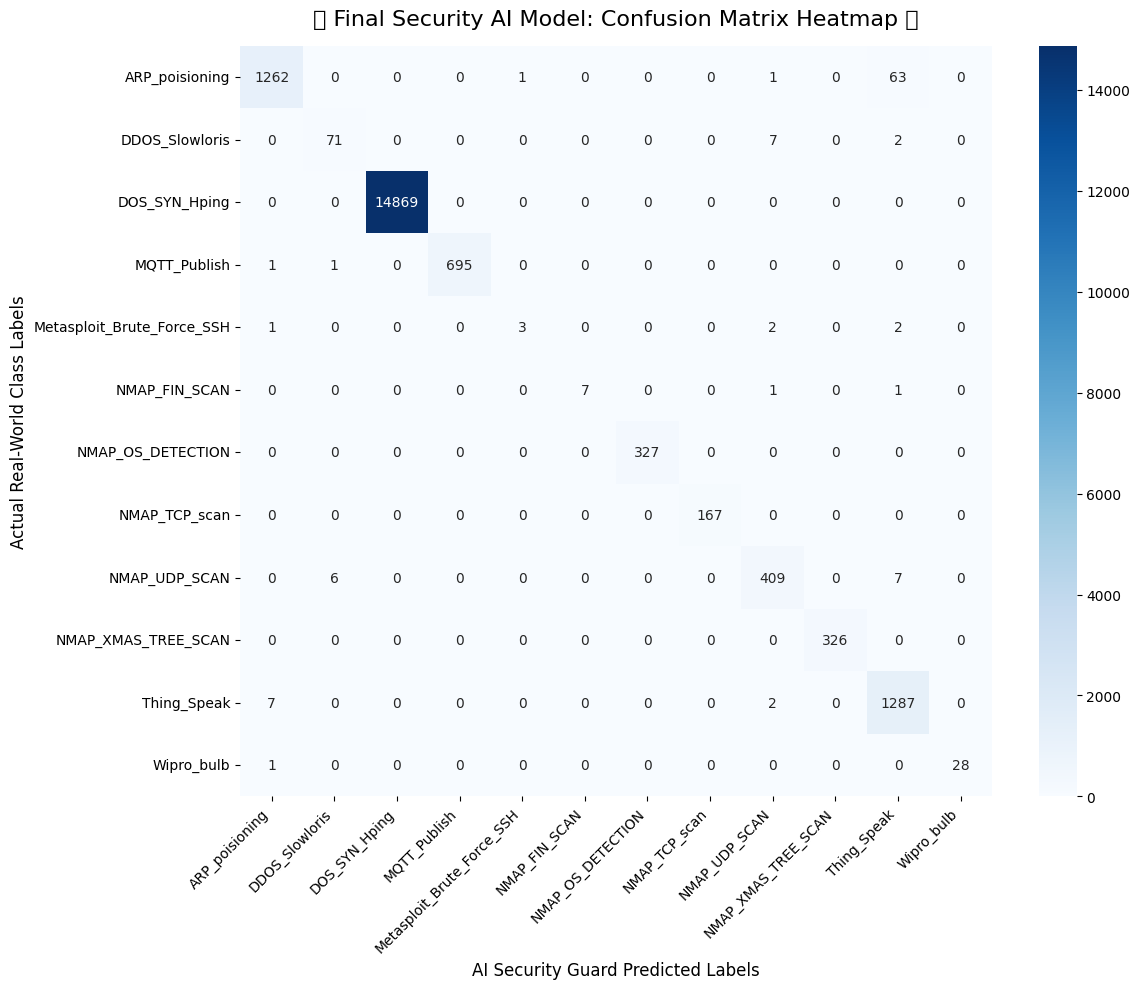

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# 1. Calculate the raw confusion matrix grid
cm = confusion_matrix(y_test, final_test_predictions)

# 2. Set up the plotting canvas size (12x10 ensures 12 labels fit comfortably)
plt.figure(figsize=(12, 10))

# 3. Create the heatmap using seaborn
# 'annot=True' prints the actual row counts inside the squares
# 'fmt="d"' forces the numbers to display as clean integers
# 'cmap="Blues"' uses a professional blue gradient
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)

# 4. Add clear, professional titles and axis markings
plt.title("Final Security AI Model: Confusion Matrix Heatmap", fontsize=16, pad=15)
plt.ylabel("Actual Real-World Class Labels", fontsize=12)
plt.xlabel("AI Security Guard Predicted Labels", fontsize=12)

# 5. Rotate labels so they don't overlap with each other
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 6. Adjust layout and render the final plot image
plt.tight_layout()
plt.show()



## 16. Conclusion


Here, based on the empirical validation metrics, the **Random Forest Classifier** is selected as the champion model for the RT-IoT2022 dataset pipeline due to its superior performance across all evaluation dimensions:

### Comparative Analysis Matrix
* **Random Forest (Champion):** Achieved the highest overall validation accuracy of **99.75%**, a Weighted F1-score of **0.9975**, and an exceptional Macro F1-score of **0.9583**. This high macro metric proves that the model successfully balances detections across both high-volume floods and rare minority attack vectors.
* **Logistic Regression:** Delivered a competitive accuracy of **99.19%** and a Macro F1 of **0.9200**, demonstrating strong robustness after hyperparameter tuning and optimization.
* **AdaBoost:** Performed reliably but fell slightly behind the ensemble configurations, yielding **97.94%** accuracy and a **0.9136** Macro F1-score.

